In [2]:
from google.colab import files
uploaded = files.upload()

Saving listings.csv to listings.csv


In [26]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [27]:
df = pd.read_csv("listings.csv")

keep_cols = ["id", "name", "host_id", "host_name", "neighbourhood",
             "room_type", "price", "minimum_nights", "number_of_reviews",
             "reviews_per_month", "availability_365"]
df = df[[c for c in keep_cols if c in df.columns]]

if df["price"].dtype == object:
    df["price"] = df["price"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)

df = df.dropna(subset=["price"])
df = df[df["price"] > 0]

In [28]:
# Drop rows with missing neighbourhood (fixes the "None" bucket issue)
df = df.dropna(subset=["neighbourhood"])

# Clean up messy neighbourhood text (fixes duplicate names like
# "Rio De Janeiro, Rj" vs "Rio de Janeiro , Rio de Janeiro, Brazil")
df["neighbourhood"] = df["neighbourhood"].str.strip().str.title()

# Check price stats to spot outliers
print(df["price"].describe())

count     16739.000000
mean        691.176116
std        6813.377197
min          38.000000
25%         189.000000
50%         300.000000
75%         533.500000
max      562031.000000
Name: price, dtype: float64


In [29]:
price_cap = df["price"].quantile(0.99)
df = df[df["price"] <= price_cap]
print(f"Capped prices above {price_cap}, {len(df)} listings remain")

Capped prices above 5000.0, 16603 listings remain


In [30]:
conn = sqlite3.connect("airbnb.db")
df.to_sql("listings", conn, if_exists="replace", index=False)

16603

In [31]:
q1 = """
SELECT neighbourhood, ROUND(AVG(price), 2) AS avg_price, COUNT(*) AS num_listings
FROM listings
GROUP BY neighbourhood
HAVING num_listings >= 5
ORDER BY avg_price DESC
LIMIT 15
"""
df1 = pd.read_sql_query(q1, conn)
df1

,neighbourhood,avg_price,num_listings
0,"Joá, Rio De Janeiro, Brazil",1803.57,23
1,"Santa Cruz, Rio De Janeiro, Brazil",1314.50,6
2,"Rj, Rio De Janeiro, Brazil",1043.20,5
3,"Recreio Dos Bandeir, Rio De Janeiro, Brazil",1002.80,5
4,"São Conrado, Rio De Janeiro, Brazil",868.34,35
5,"Rio De Janeiro, Rj, Brazil",824.16,25
6,"Gávea, Rio De Janeiro, Brazil",791.19,37
7,"Itanhangá, Rio De Janeiro, Brazil",747.36,44
8,"Rio De Janeiro, Rio De Janeiro, Brazil",718.74,47
9,"Lagoa, Rio De Janeiro, Brazil",695.52,31


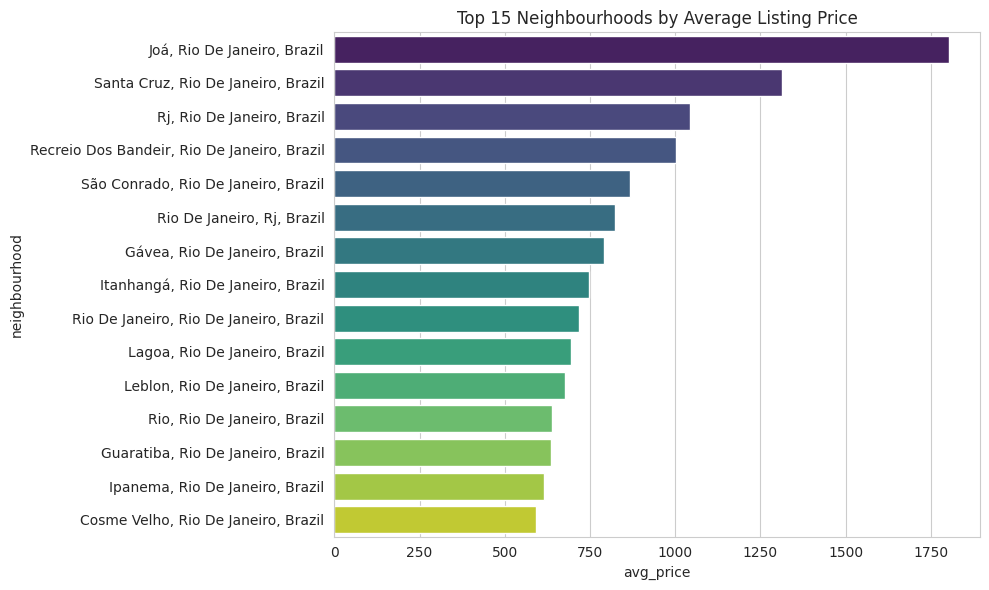

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df1, x="avg_price", y="neighbourhood", hue="neighbourhood", palette="viridis", legend=False)
plt.title("Top 15 Neighbourhoods by Average Listing Price")
plt.tight_layout()
plt.savefig("price_by_neighbourhood.png", dpi=150)
plt.show()

In [33]:
from google.colab import files
files.download("price_by_neighbourhood.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
df.sort_values("price", ascending=False).head(5)

,id,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
7171,16989942,Rental unit in rio de janeiro · ★4.89 · 2 bedr...,113778336,Diogo,"Rio De Janeiro, Rio De Janeiro, Brazil",Entire home/apt,5000.0,2,19,0.28,356
7007,16683820,Rental unit in Rio de Janeiro · 4 bedrooms · 4...,29331245,Monica,"Rio De Janeiro, Brazil",Entire home/apt,5000.0,3,0,NaN,365
7313,17636141,Rental unit in Rio de Janeiro · ★4.86 · 2 bedr...,101963765,Junior E Célia,"Rio De Janeiro, Brazil",Private room,5000.0,1,29,0.37,126
12817,42137547,Rental unit in Ipanema · 3 bedrooms · 3 beds ·...,146347544,Frédéric,"Ipanema, Rio De Janeiro, Brazil",Entire home/apt,5000.0,3,0,NaN,358
6986,16620678,Home in Rio de Janeiro · 2 bedrooms · 1 bed · ...,109739204,Luan,"Rio De Janeiro, Brazil",Entire home/apt,5000.0,1,1,0.01,0


In [35]:
q2 = """
SELECT room_type, ROUND(AVG(price), 2) AS avg_price, COUNT(*) AS num_listings
FROM listings
GROUP BY room_type
ORDER BY avg_price DESC
"""
df2 = pd.read_sql_query(q2, conn)
df2

,room_type,avg_price,num_listings
0,Entire home/apt,542.47,13105
1,Hotel room,392.41,29
2,Private room,269.70,3230
3,Shared room,195.15,239


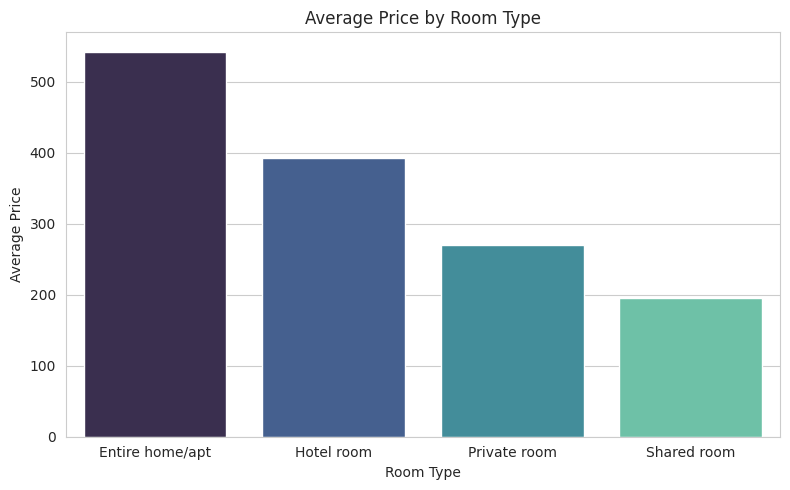

In [36]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df2, x="room_type", y="avg_price", hue="room_type", palette="mako", legend=False)
plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price")
plt.tight_layout()
plt.savefig("price_by_room_type.png", dpi=150)
plt.show()

In [37]:
q3 = """
SELECT host_id, host_name, COUNT(*) AS num_listings
FROM listings
GROUP BY host_id, host_name
ORDER BY num_listings DESC
LIMIT 10
"""
df3 = pd.read_sql_query(q3, conn)
df3

,host_id,host_name,num_listings
0,91654021,Daniel,159
1,6000862,Omar Do Rio,126
2,30165706,Yes Temporada,66
3,74463624,Mozart,61
4,46664224,Rafael,51
5,13580277,Marcio,48
6,49207110,Anfitriao Gente Boa,36
7,2513825,Further,33
8,160833906,RioHost,30
9,60298129,Danide,28


In [38]:
q4 = """
SELECT
    CASE
        WHEN number_of_reviews = 0 THEN '0 reviews'
        WHEN number_of_reviews BETWEEN 1 AND 10 THEN '1-10'
        WHEN number_of_reviews BETWEEN 11 AND 50 THEN '11-50'
        ELSE '50+'
    END AS review_bucket,
    ROUND(AVG(price), 2) AS avg_price,
    COUNT(*) AS num_listings
FROM listings
GROUP BY review_bucket
ORDER BY avg_price DESC
"""
df4 = pd.read_sql_query(q4, conn)
df4

,review_bucket,avg_price,num_listings
0,0 reviews,814.04,2595
1,1-10,488.38,6291
2,11-50,384.27,5042
3,50+,342.41,2675


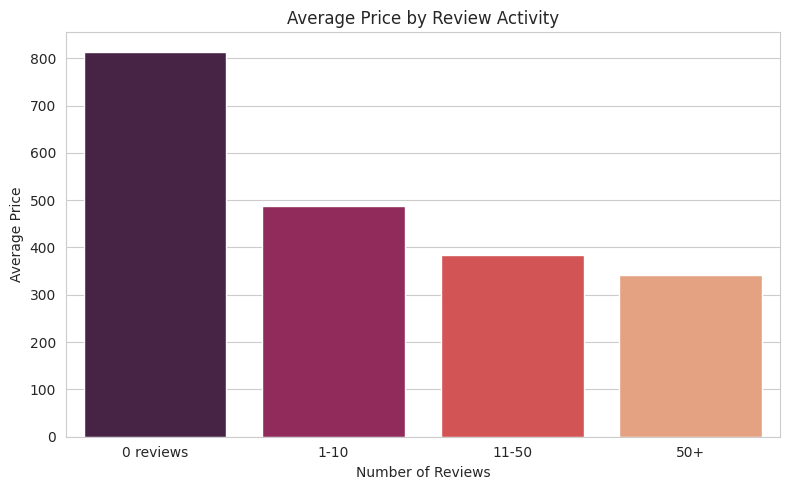

In [39]:
plt.figure(figsize=(8, 5))
order = ["0 reviews", "1-10", "11-50", "50+"]
sns.barplot(data=df4, x="review_bucket", y="avg_price", order=order, hue="review_bucket", palette="rocket", legend=False)
plt.title("Average Price by Review Activity")
plt.xlabel("Number of Reviews")
plt.ylabel("Average Price")
plt.tight_layout()
plt.savefig("price_by_reviews.png", dpi=150)
plt.show()